# Waypoint Constraints

This example constrains a cruise trajectory from Amsterdam Schiphol (`EHAM`) to Frankfurt (`EDDF`) through named fixes from OpenAP's packaged navigation database.

In [1]:
import warnings

import matplotlib.pyplot as plt
import openap

import opentop as top

warnings.filterwarnings("ignore")

In [2]:
fix_names = ("ARNEM", "KENUM", "DODEN", "BOMBI")

waypoints = []
for fix_name in fix_names:
    lat, lon, _ = openap.nav.fix(fix_name)
    waypoints.append((float(lat), float(lon)))

list(zip(fix_names, waypoints))

[('ARNEM', (52.096447, 6.076603)),
 ('KENUM', (50.7225, 6.239444)),
 ('DODEN', (50.617222, 8.0825)),
 ('BOMBI', (50.056667, 8.800278))]

In [3]:
optimizer = top.Cruise("A320", "EHAM", "EDDF", 0.85)

flight = optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=20_000,
)

fuel_burn = flight.mass.iloc[0] - flight.mass.iloc[-1]
elapsed_time = flight.ts.iloc[-1] / 60

print("Route: EHAM -> " + " -> ".join(fix_names) + " -> EDDF")
print(f"Fuel burn: {fuel_burn:.1f} kg")
print(f"Elapsed time: {elapsed_time:.1f} min")

Route: EHAM -> ARNEM -> KENUM -> DODEN -> BOMBI -> EDDF
Fuel burn: 1304.2 kg
Elapsed time: 28.3 min


In [4]:
for fix_name, waypoint in zip(fix_names, waypoints):
    distances = [
        openap.aero.distance(lat, lon, waypoint[0], waypoint[1])
        for lat, lon in zip(flight.latitude, flight.longitude)
    ]
    print(f"{fix_name}: closest trajectory point {min(distances) / 1000:.1f} km")

ARNEM: closest trajectory point 19.9 km
KENUM: closest trajectory point 20.0 km
DODEN: closest trajectory point 20.0 km
BOMBI: closest trajectory point 19.2 km


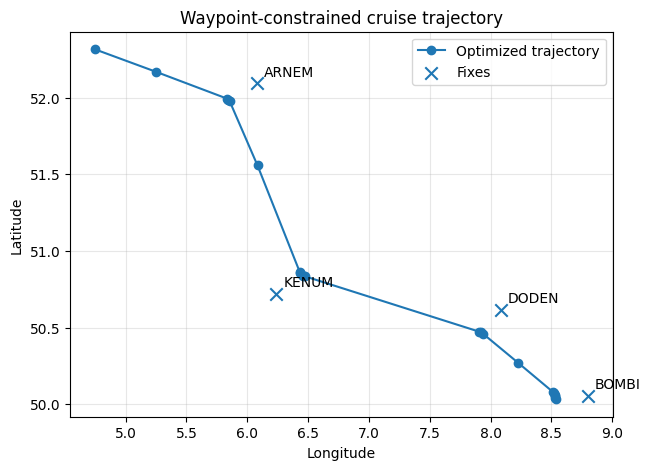

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(flight.longitude, flight.latitude, marker="o", label="Optimized trajectory")
ax.scatter(
    [lon for _, lon in waypoints],
    [lat for lat, _ in waypoints],
    marker="x",
    s=80,
    label="Fixes",
)

for fix_name, (lat, lon) in zip(fix_names, waypoints):
    ax.annotate(fix_name, (lon, lat), xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Waypoint-constrained cruise trajectory")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()